# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Kalkstein 80°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 1092
Average Fx in the averaging interval [680:1772]: 6.0319886187930685
Average Fz in the averaging interval [680:1772]: 1.832951427641369
Maximum Fz in the plotting interval [680:None]: 4.10086669921875 at timestep 1762
Time step where Fx drops below 1: 1772


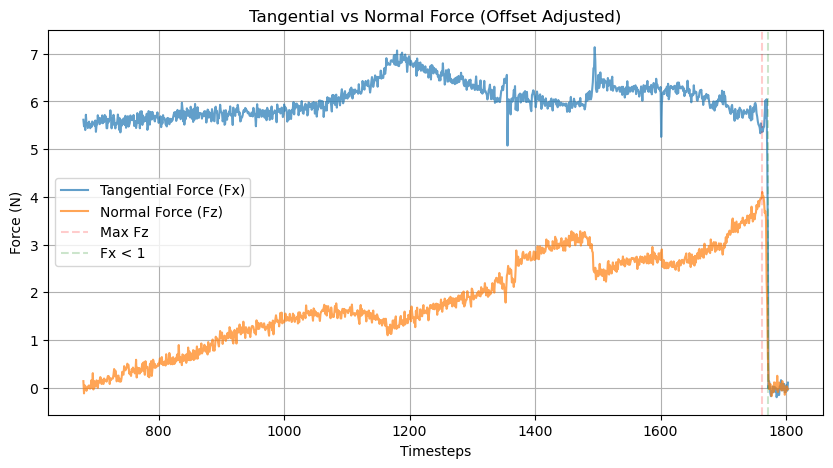

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281027.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=680, cut_2=None, avg_end=1772, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 518
Average Fx in the averaging interval [945:1463]: 5.974494573539134
Average Fz in the averaging interval [945:1463]: 0.9535259939068533
Maximum Fz in the plotting interval [945:None]: 1.83724365234375 at timestep 1460
Time step where Fx drops below 1: 1465


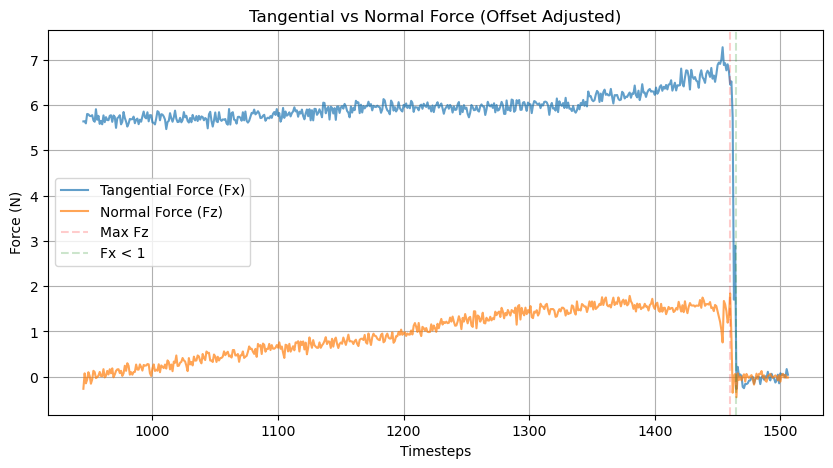

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281028.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=945, cut_2=None, avg_end=1463, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 191
Average Fx in the averaging interval [1070:1261]: 5.379251565483852
Average Fz in the averaging interval [1070:1261]: 0.42862610608911433
Maximum Fz in the plotting interval [1070:None]: 0.8743815104166667 at timestep 1236
Time step where Fx drops below 1: 1261


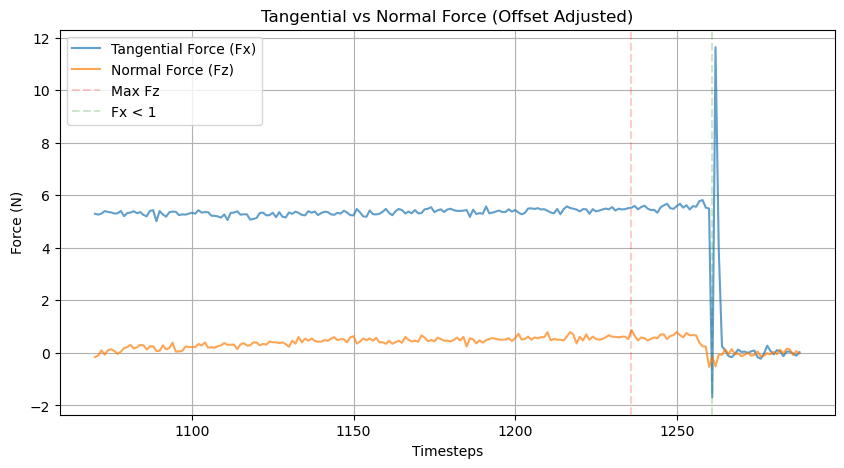

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281030.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=1070, cut_2=None, avg_end=1261, offset_position='end', offset_length=15)

<font size="6">Test 4a: (worked)</font>

Length from cut_1 to avg_end: 175
Average Fx in the averaging interval [600:775]: 5.30049119313558
Average Fz in the averaging interval [600:775]: 0.13028111049107144
Maximum Fz in the plotting interval [600:785]: 0.67347412109375 at timestep 758
Time step where Fx drops below 1: 775


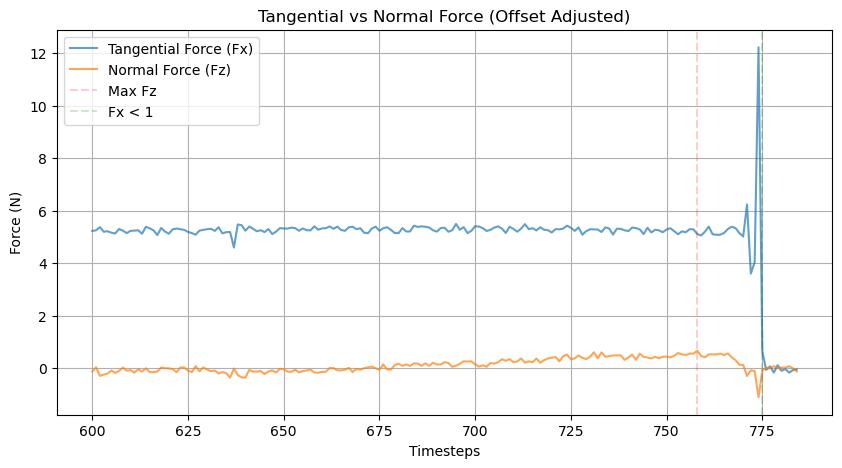

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281031.csv"
df = pd.read_csv(data)
test_4a, end_4a = plot_forces(df, cut_1=600, cut_2=785, avg_end=775, offset_position='beginning', offset_length=15)

<font size="6">Test 4b: (worked)</font>

Length from cut_1 to avg_end: 387
Average Fx in the averaging interval [1520:1907]: 6.157512626105809
Average Fz in the averaging interval [1520:1907]: 0.4419684042918282
Maximum Fz in the plotting interval [1520:None]: 1.2927571614583333 at timestep 1891
Time step where Fx drops below 1: 1908


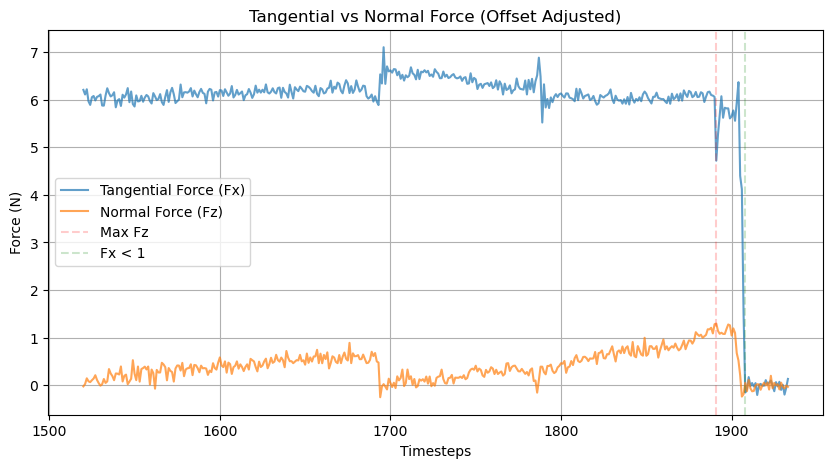

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281031.csv"
df = pd.read_csv(data)
test_4b, end_4b = plot_forces(df, cut_1=1520, cut_2=None, avg_end=1907, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 648
Average Fx in the averaging interval [810:1458]: 6.029113840615308
Average Fz in the averaging interval [810:1458]: 0.8608286916473764
Maximum Fz in the plotting interval [810:None]: 2.2101765950520833 at timestep 1438
Time step where Fx drops below 1: 1458


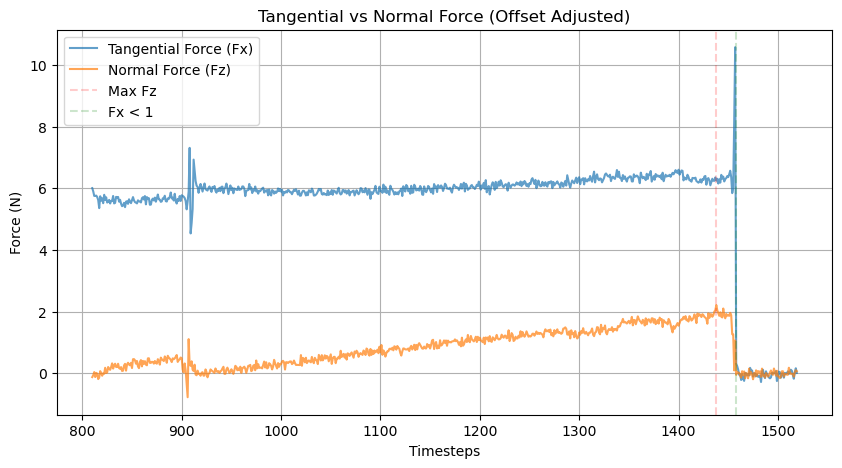

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281032.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=810, cut_2=None, avg_end=1458, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 453
Average Fx in the averaging interval [1120:1573]: 5.835296883698857
Average Fz in the averaging interval [1120:1573]: 0.8769304624982753
Maximum Fz in the plotting interval [1120:None]: 1.39029541015625 at timestep 1552
Time step where Fx drops below 1: 1573


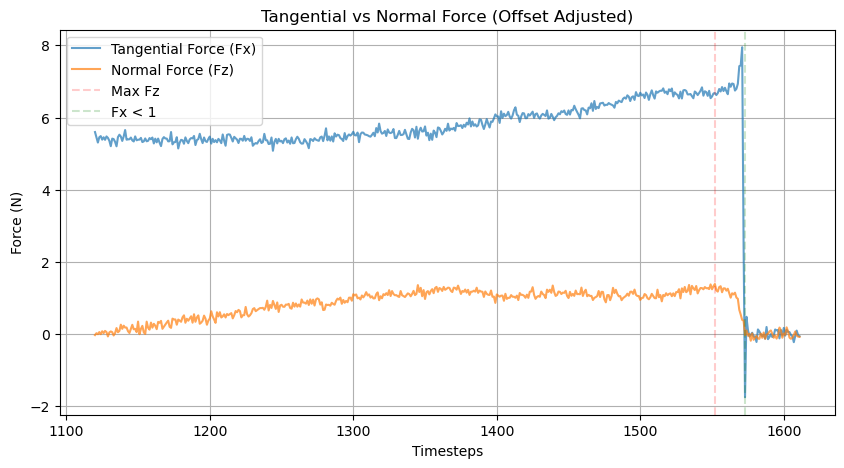

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281033.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=1120, cut_2=None, avg_end=1573, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 133
Average Fx in the averaging interval [1000:1133]: 6.452578092159185
Average Fz in the averaging interval [1000:1133]: 0.3128717484629543
Maximum Fz in the plotting interval [1000:None]: 0.6675699869791667 at timestep 1095
Time step where Fx drops below 1: 1133


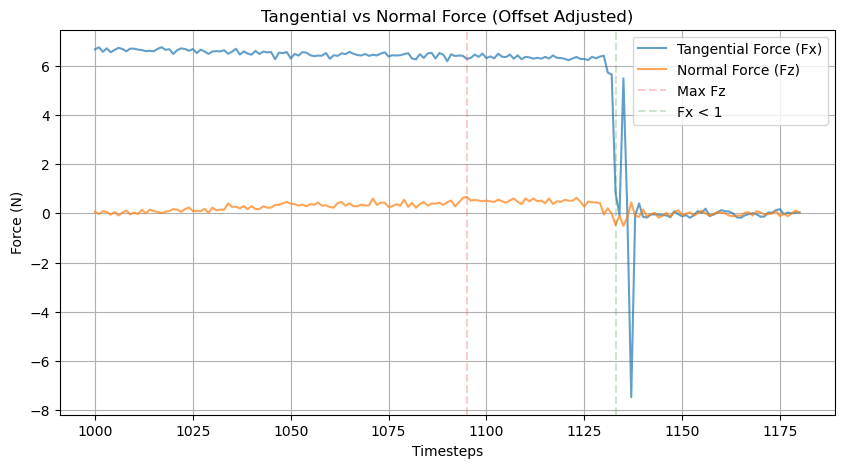

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281035.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=1000, cut_2=None, avg_end=1133, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 269
Average Fx in the averaging interval [940:1209]: 5.8781839217099705
Average Fz in the averaging interval [940:1209]: 0.47199044493494424
Maximum Fz in the plotting interval [940:None]: 1.0544677734375 at timestep 1203
Time step where Fx drops below 1: 1209


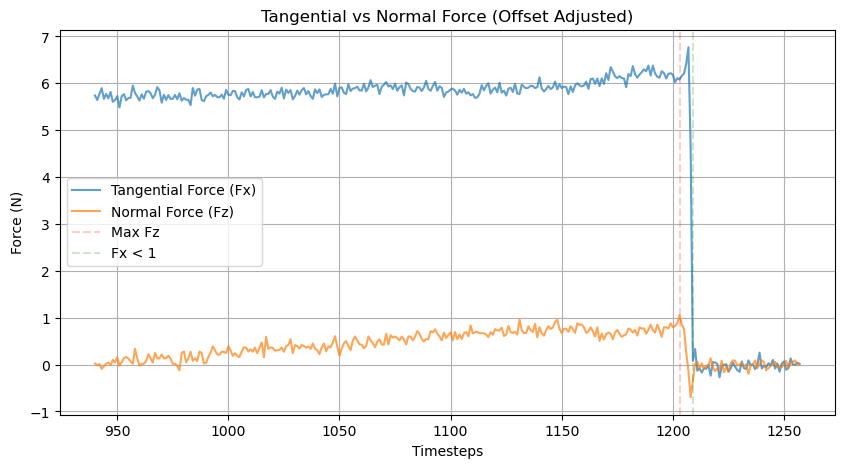

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281036.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=940, cut_2=None, avg_end=1209, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 265
Average Fx in the averaging interval [1050:1315]: 6.976621991883285
Average Fz in the averaging interval [1050:1315]: 0.7190603963983885
Maximum Fz in the plotting interval [1050:None]: 1.6089396158854168 at timestep 1305
Time step where Fx drops below 1: 1315


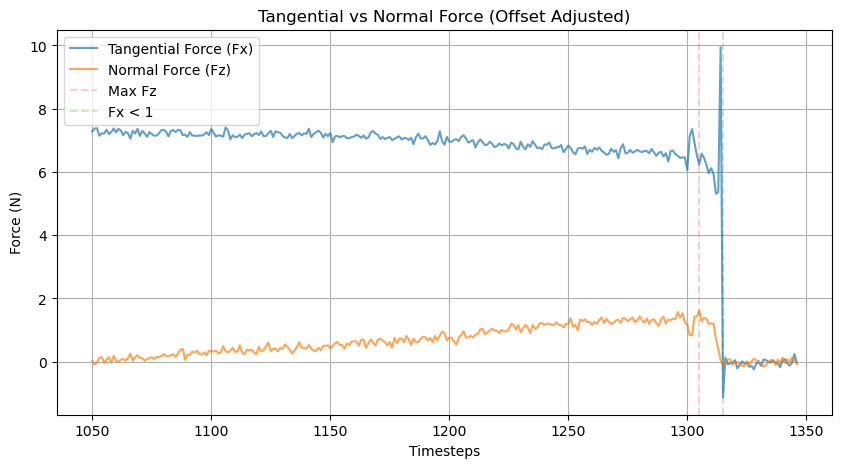

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281038.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=1050, cut_2=None, avg_end=1315, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 617
Average Fx in the averaging interval [1000:1617]: 6.7307395905433385
Average Fz in the averaging interval [1000:1617]: 0.5736718011378985
Maximum Fz in the plotting interval [1000:None]: 1.7925089518229167 at timestep 1598
Time step where Fx drops below 1: 1617


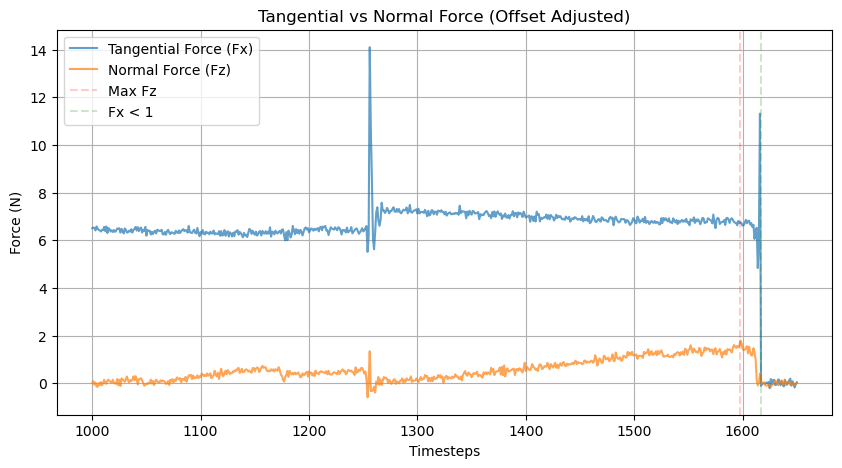

In [13]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281040.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=1000, cut_2=None, avg_end=1617, offset_position='end', offset_length=15)

<font size="6">Test 11: (worked)</font>

Length from cut_1 to avg_end: 397
Average Fx in the averaging interval [1080:1477]: 5.448550795948275
Average Fz in the averaging interval [1080:1477]: 1.0419195705256876
Maximum Fz in the plotting interval [1080:None]: 2.4252115885416665 at timestep 1141
Time step where Fx drops below 1: 1477


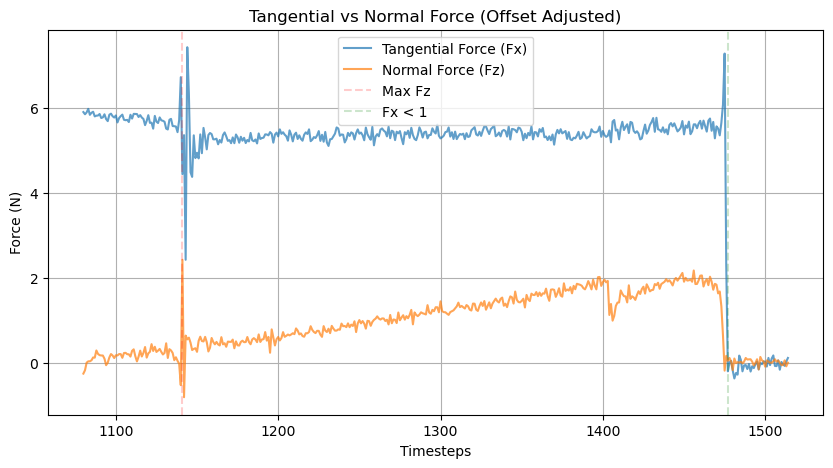

In [14]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_80_5N//log_202405281041.csv"
df = pd.read_csv(data)
test_11, end_11 = plot_forces(df, cut_1=1080, cut_2=None, avg_end=1477, offset_position='end', offset_length=15)

In [15]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [19]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//80//Kalkstein_80_stats.csv", index=False)

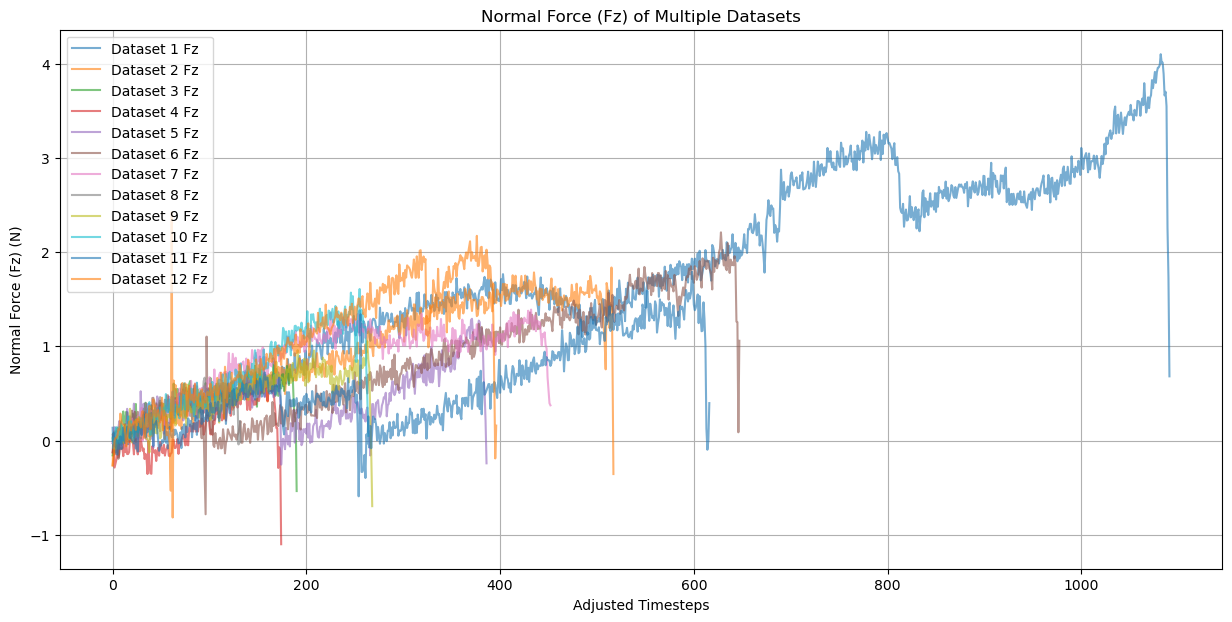

Average of maximum Fz forces: 1.6606577555338544
Standard deviation of maximum Fz forces: 0.9150261110747935
Average of average Fz forces: 0.7203855131688134
Standard deviation of average Fz forces: 0.4281675341072293
Average of average Fx forces: 6.016235307801305
Standard deviation of average Fx forces: 0.4947617356389985


In [20]:
tests = [test_1, test_2, test_3, test_4a, test_4b, test_5, test_6, test_7, test_8, test_9, test_10, test_11]
ends = [end_1, end_2, end_3, end_4a, end_4b, end_5, end_6, end_7, end_8, end_9, end_10, end_11]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [21]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//80//Kalkstein_80"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)